In [1]:
import torch
import torch.nn as nn
import torch.distributions as dist
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
# 設置種子
seed = 42
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(type(device))
print(device)

<class 'torch.device'>
cpu


# Dataset

In [4]:
def generate_dataset(num_samples, dim=100):
    '''
    向量的前半維度的值 = 向量後半維度的值 -> 這樣設計理論上要能降到一半維度
    總共要幾筆向量
    每個向量的維度
    '''
    # 前50维随机生成 0 或 1
    first_half = torch.randint(0, 2, (num_samples, dim // 2), dtype=torch.float)
    
    # 后50维复制前50维
    second_half = first_half.clone()
    
    # 拼接前50维和后50维
    return torch.cat((first_half, second_half), dim=1)

In [5]:
dataset_train = generate_dataset(10000, 100)
dataset_test  = generate_dataset(10, 100)

# Model

In [6]:
class bVAE(nn.Module):
    
    def __init__(self, N, K):
        
        super().__init__()

        self.N = N
        self.K = K
        self.temperature = 1.0
        
        self.encoder = nn.Sequential(
            nn.Linear(100, 75),
            nn.LeakyReLU(),
            nn.Linear(75, self.N * self.K)
        )
        
        self.decoder = torch.nn.Sequential(
            nn.Linear(self.N * self.K, 75),
            nn.LeakyReLU(),
            nn.Linear(75, 100),
            nn.Sigmoid()
        )
        
    def encode(self, inputs):
        '''
        input
        - inputs.shape: [batch_size, flatten_img_size]
        output
        - logits.shape: [batch_size, N*K]
        '''
        logits = self.encoder(inputs)
        return logits

    def decode(self, latent_codes):
        '''
        input
        - latent_codes.shape: [batch_size, N*K]
        output
        - outputs.shape: [batch_size, flatten_img_size]
        '''
        outputs = self.decoder(latent_codes)
        return outputs

    def gumbel_dist(self, shape, eps=1e-20):
        '''
        input
        - shape.shape: [batch_size, N*K]
        output
        - gumbel_noise.shape: [batch_size, N*K]
        '''
        U = torch.rand(shape)
        gumbel_noise = -torch.log(-torch.log(U + eps) + eps)
        return gumbel_noise

    def gumbel_softmax(self, logits, temperature):
        '''
        input
        - logits.shape: [batch_size, N*K]
        - temperature.shape: [1]
        output
        - latent_codes.shape: [batch_size, N*K]
        '''
        # Reshape to [batch_size*N, K]
        batch_size = len(logits)
        logits = logits.view(batch_size * self.N, self.K)
        gumbel_noise = self.gumbel_dist(logits.shape)
        y = logits + gumbel_noise
        latent_codes = nn.functional.softmax(y / temperature, dim=-1)

        # Reshape back to [batch_size, N*K]
        logits = logits.view(batch_size, self.N * self.K)
        latent_codes = latent_codes.view(batch_size, self.N * self.K)

        return latent_codes
    
    def forward(self, inputs, temperature):
        '''
        input
        - inputs.shape: [batch_size, flatten_img_size]
        output
        - logits.shape: [batch_size, N*K]
        - latent_codes.shape: [batch_size, N*K]
        - outputs.shape: [batch_size, flatten_img_size]
        '''
        logits = self.encode(inputs)
        latent_codes = self.gumbel_softmax(logits, temperature)
        outputs = self.decoder(latent_codes)
        return logits, latent_codes, outputs

# Train

In [7]:
batch_size = 100
epochs = 100
learning_rate = 0.001
initial_temperature = 0.5
minimum_temperature = 0.1
temperature_anneal_rate = 0.00003
K = 2 # number of classes
N = 50 # number of categorical distributions

In [8]:
# DataLoader
dataloader_train = DataLoader(dataset=dataset_train,
                              batch_size=batch_size,
                              shuffle=True)

In [9]:
# Loss Function
def cat_kl_div(logits):
    '''
    input
    - logits.shape: [batch_size, N*K]
    output
    - kl.shape: [batch_size, N]
    '''
    # Reshape to [batch_size*N, K]
    batch_size = len(logits)
    logits = logits.view(batch_size*N, K)
    
    q = dist.Categorical(logits=logits)
    p = dist.Categorical(probs=torch.full((batch_size*N, K), 1.0/K)) # uniform bunch of K-class categorical distributions
    kl = dist.kl.kl_divergence(q, p) # kl is of shape [B*N]
    return kl.view(batch_size, N)

def loss_func(outputs, labels, logits):
    '''
    input
    - outputs.shape: [batch_size, flatten_img_size]
    - labels.shape: [batch_size, flatten_img_size]
    - logits.shape: [batch_size, N*K]
    '''
    # rec_loss = (nn.functional.binary_cross_entropy(outputs, inputs, reduction="none").sum()) / inputs.shape[0]
    # rec_loss = (nn.functional.cross_entropy(outputs, inputs, reduction="none").sum()) / inputs.shape[0]
    aaaa = nn.MSELoss()
    rec_loss = aaaa(outputs, labels)
    kl_loss = torch.mean(torch.sum(cat_kl_div(logits), dim=1))
    loss = rec_loss + kl_loss
    return loss

In [10]:
model = bVAE(N, K)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
temperature = initial_temperature

In [11]:
# Train
model.train()

for epoch in range(epochs):
    
    total_loss = 0
    rec_loss = 0
    kl_loss = 0
    cnt = 0
    
    for data in dataloader_train:
        '''
        data.shape: [batch_size, vector]
        '''
        
        # Clear Gradients
        model.zero_grad()

        inputs = data
        '''
        inputs.shape: [batch_size, vector]
        '''
        
        # Forward
        logits, latent_codes, outputs = model(inputs, temperature)
        '''
        - logits.shape: [batch_size, N*K]
        - latent_codes.shape: [batch_size, N*K]
        - outputs.shape: [batch_size, vector]
        '''
        
        # Calculate the Loss
        loss = loss_func(outputs, inputs, logits)
        total_loss += loss.item()
        
        # Backward & Update the parameters
        loss.backward()
        optimizer.step()

    cnt += 1
    temperature = np.maximum(initial_temperature*np.exp(-temperature_anneal_rate*cnt), minimum_temperature)

    avg_loss = total_loss / len(dataloader_train.dataset)
    if epoch % 10 == 0:
        print(f"{epoch+1:>3}. avg_loss: {avg_loss:.7f}, rec_loss: {rec_loss:.7f}, kl_loss: {kl_loss:.7f}")
    # for param in model.parameters():
    #     print(f"{param.grad}")
    # print("------------------------------")

  1. avg_loss: 0.0028019, rec_loss: 0.0000000, kl_loss: 0.0000000
 11. avg_loss: 0.0025002, rec_loss: 0.0000000, kl_loss: 0.0000000
 21. avg_loss: 0.0025000, rec_loss: 0.0000000, kl_loss: 0.0000000
 31. avg_loss: 0.0025000, rec_loss: 0.0000000, kl_loss: 0.0000000
 41. avg_loss: 0.0025000, rec_loss: 0.0000000, kl_loss: 0.0000000
 51. avg_loss: 0.0024999, rec_loss: 0.0000000, kl_loss: 0.0000000
 61. avg_loss: 0.0025000, rec_loss: 0.0000000, kl_loss: 0.0000000
 71. avg_loss: 0.0024999, rec_loss: 0.0000000, kl_loss: 0.0000000
 81. avg_loss: 0.0024999, rec_loss: 0.0000000, kl_loss: 0.0000000
 91. avg_loss: 0.0024999, rec_loss: 0.0000000, kl_loss: 0.0000000


In [12]:
# Save Model
# torch.save(model.state_dict(), 'bVAE_model_weights.pth')

# Test

In [13]:
# Load Model
# model.load_state_dict(torch.load('bVAE_model_weights.pth', weights_only=True))

In [14]:
batch_size = 2

In [15]:
# DataLoader
dataloader_test = DataLoader(dataset_test,
                             batch_size=batch_size,
                             shuffle=True)

In [16]:
# Show Image
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

def show_logits(logits):
    '''
    input
    - logits.shape: [batch_size, N*K]
    '''
    sqrtn = int(np.ceil(np.sqrt(logits.shape[0])))
    for index, logit in enumerate(logits):
        plt.subplot(sqrtn, sqrtn, index+1)
        plt.imshow(logit.reshape(N, K))
        plt.axis('off')
    plt.show()

inputs.shape: torch.Size([2, 100])
tensor([[0., 1., 1., 0., 1., 0., 0., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0.,
         1., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 1., 1., 0., 1., 0., 0., 1.,
         0., 1., 1., 1., 0., 0., 1., 1., 1., 0., 0., 0., 0., 1., 0., 1., 1., 0.,
         1., 0., 0., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 1., 0., 0., 0.,
         1., 0., 0., 1., 1., 0., 0., 1., 1., 0., 1., 0., 0., 1., 0., 1., 1., 1.,
         0., 0., 1., 1., 1., 0., 0., 0., 0., 1.],
        [0., 1., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 1., 0., 1., 1.,
         1., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 1.,
         1., 0., 0., 0., 1., 1., 1., 0., 1., 0., 1., 0., 0., 1., 0., 1., 1., 0.,
         0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 1., 0., 1., 1., 1., 0., 0., 1.,
         0., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 1., 1., 0., 0., 0.,
         1., 1., 1., 0., 1., 0., 1., 0., 0., 1.]])
logits.shape: torch.Size([2, 100])


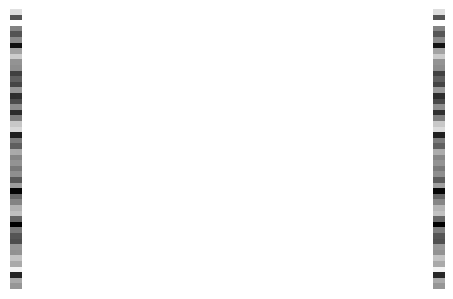

latent_code.shape: torch.Size([2, 100])


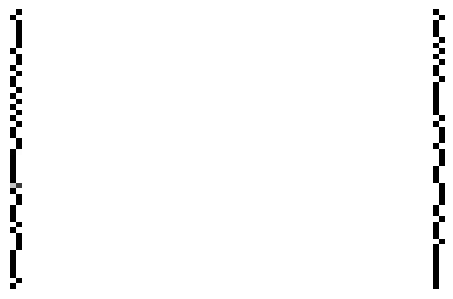

outputs.shape: torch.Size([2, 100])
tensor([[1., 1., 0., 1., 0., 0., 1., 0., 0., 1., 1., 0., 1., 0., 1., 1., 0., 1.,
         1., 1., 1., 1., 0., 0., 0., 1., 0., 1., 0., 1., 1., 1., 1., 0., 0., 1.,
         1., 1., 1., 1., 1., 0., 1., 0., 1., 0., 1., 0., 0., 0., 0., 1., 0., 1.,
         0., 0., 1., 0., 0., 1., 1., 0., 1., 0., 1., 1., 0., 1., 1., 1., 1., 1.,
         0., 0., 0., 1., 0., 1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 0.,
         1., 0., 1., 1., 1., 0., 1., 1., 0., 0.],
        [1., 1., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 1., 1., 0., 1.,
         1., 1., 1., 1., 0., 0., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 0., 1.,
         1., 1., 1., 1., 1., 0., 1., 0., 1., 0., 1., 1., 0., 0., 1., 1., 0., 1.,
         0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 1., 1., 0., 1., 1., 1., 1., 1.,
         0., 0., 1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 0.,
         1., 0., 1., 1., 1., 1., 1., 1., 0., 0.]])
tensor([45, 49])


In [17]:
model.eval()

with torch.no_grad():
    
    for data in dataloader_test:
    
        inputs = data
        print("inputs.shape:", inputs.shape)
    
        # Inputs
        print(inputs)
    
        # Inference/Forward
        logits, latent_code, outputs = model(inputs, temperature=0.01)
        '''
        - logits.shape: [batch_size, N*K]
        - latent_codes.shape: [batch_size, N*K]
        - outputs.shape: [batch_size, vector]
        '''
        
        # Logits
        print("logits.shape:", logits.shape)
        show_logits(logits)

        # Latent Code
        print("latent_code.shape:", latent_code.shape)
        show_logits(latent_code)
        
        # Outputs
        print("outputs.shape:", outputs.shape)
        # print(outputs)

        outputs = (outputs>=0.5).int().float()
        print(outputs)

        difference = inputs != outputs
        # 計算每個維度不相等的元素數量
        row_differences = torch.sum(difference, dim=1)  # 每行的不同數量
        print(row_differences)
        
        # 用得到的logits丟到decode看生出來的會不會一樣
        # model.decode(logits)
        
        break

# Generation

In [18]:
# batch_size = 100
# temperature = 0.01
# with torch.no_grad():
#     logits = torch.rand((batch_size, N, K))
#     latent_code = model.gumbel_softmax(logits, temperature)
#     gen_img = model.decode(latent_code)
#     show_images(gen_img)